### 7.3 Pretrained Faster R-CNN Model

⚠️⚠️⚠️ *Please open this notebook in Google Colab* by click below link ⚠️⚠️⚠️<br><br>
<a href="https://colab.research.google.com/github/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/7.3%20pretrained_faster_rcnn.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><br><br><br>
- Click `Connect` button in top right Google Colab notebook,<br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/resource/cl-connect-gpu.png?raw=1" width="250px">
- If connecting process completed, it will turn to something look like this<br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/resource/cl-connect-gpu-success.png?raw=1" width="250px">

- Check GPU connected into Colab environment is active

In [1]:
!nvidia-smi

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


In [8]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio

  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/114.6 MB 1.2 MB/s eta 0:01:40
   ---------------------------------------- 0.8/114.6 MB 1.2 MB/s eta 0:01:39
   ---------------------------------------- 1.0/114.6 MB 1.2 MB/s eta 0:01:38
   ---------------------------------------- 1.3/114.6 MB 1.1 MB/s eta 0:01:45
    --------------------------------------- 1.6/114.6 MB 1.1 MB/s eta 0:01:46
   

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2

- Define COCO Class Names (91 class)

In [10]:
COCO_CLASS_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']

- Load image Sample

In [11]:
# Download an example image from repo
import urllib
url, filename = ("https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/raw/main/Pertemuan%207/image2.jpg", "image2.jpg")
try: urllib.URLopener().retrieve(url, filename)
except: urllib.request.urlretrieve(url, filename)

In [12]:
# show image using matplot lib
def imshow(image, isBGR=True):
    if isBGR :
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.axis("off")

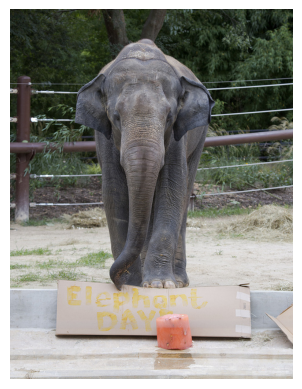

In [7]:
# Load an example image and preprocess it
image_path = 'image2.jpg'  # Replace with your image path
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert image to tensor and normalize as required by ResNet
input_tensor = torch.tensor(image).float().permute(2, 0, 1).unsqueeze(0)
input_tensor = input_tensor / 255.0


imshow(image, isBGR=False)

- Load Pretrained Faster R-CNN with backbone ResNet-50
    - The pretrained model provoded by Torchvision 

In [13]:
# Load the Faster R-CNN model pre-trained on COCO dataset from Torch Vision
model = fasterrcnn_resnet50_fpn_v2(
            weights='DEFAULT'
        )

# Set the model to evaluation mode
model.eval()

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to C:\Users\l430/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100.0%


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [14]:
# Perform inference
with torch.no_grad():
    predictions = model(input_tensor)

# Example: accessing the prediction results
print(predictions)  # Prints out the bounding boxes, labels, and scores


NameError: name 'input_tensor' is not defined

In [16]:
import cv2
import torch
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2

# Load model
model = fasterrcnn_resnet50_fpn_v2(pretrained=True)
model.eval()

# Baca gambar
image = cv2.imread("astronaut.jpg")  # ganti dengan file kamu
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Transform ke tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

input_tensor = transform(image)

# ⚠️ untuk detection model → pakai LIST, bukan langsung tensor
input_tensor = [input_tensor]

# Inference
with torch.no_grad():
    predictions = model(input_tensor)

print(predictions)

[{'boxes': tensor([[1.1489e+01, 3.6666e+01, 2.2989e+02, 4.0000e+02],
        [0.0000e+00, 9.8345e+01, 2.7879e+01, 3.9715e+02],
        [0.0000e+00, 3.2329e+02, 3.2309e+01, 3.9884e+02],
        [3.1361e-01, 2.1007e+01, 5.0956e+01, 3.8945e+02],
        [2.3623e-01, 1.4313e+02, 1.4895e+01, 3.9576e+02],
        [1.0829e+02, 5.7283e+01, 3.1067e+02, 4.0000e+02],
        [1.6437e+02, 2.4656e+02, 3.2079e+02, 3.9465e+02],
        [1.7420e+02, 2.5620e+02, 3.1852e+02, 4.0000e+02],
        [1.6881e+02, 2.4550e+02, 3.1582e+02, 3.8583e+02],
        [1.9196e+02, 3.8075e+02, 3.0546e+02, 3.9930e+02],
        [2.4824e+02, 2.5181e+01, 2.7808e+02, 1.6397e+02],
        [1.6810e+02, 2.4243e+02, 3.1779e+02, 3.8506e+02],
        [1.5868e+02, 2.4034e+02, 3.2035e+02, 3.9563e+02],
        [1.7089e+02, 2.4361e+02, 3.1809e+02, 3.9302e+02],
        [1.6585e+02, 2.4808e+02, 3.2100e+02, 3.9585e+02],
        [1.7169e+02, 2.4489e+02, 3.2021e+02, 3.9499e+02],
        [2.4835e+02, 2.4474e+01, 2.7684e+02, 1.6504e+02],
   

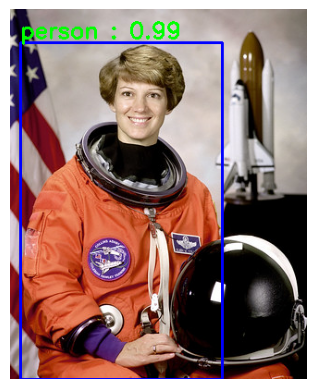

In [17]:
# Filter predictions with a threshold score
threshold = 0.89
mask = predictions[0]['scores'] > threshold
filtered_boxes = predictions[0]['boxes'][mask]
filtered_scores = predictions[0]['scores'][mask]
filtered_labels = predictions[0]['labels'][mask]


# Draw bounding boxes, labels, and confidence scores on the image
image_with_box = image.copy()

for box, score, label in zip(filtered_boxes, filtered_scores, filtered_labels):
    x_min, y_min, x_max, y_max = map(int, box)  # Extract and convert box coordinates to int
    image_with_box = cv2.rectangle(
                            image_with_box, 
                            (x_min, y_min), 
                            (x_max, y_max), 
                            color=(0, 0, 255), 
                            thickness=2
                            )

    text = f"{COCO_CLASS_NAMES[label.item()]} : {score.item():.2f}"
    image_with_box = cv2.putText(
                            image_with_box, 
                            text, 
                            (x_min, y_min - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 
                            0.8, 
                            (0, 255, 0), 
                            2
                            )

imshow(image_with_box, isBGR=False)
